# Heart Disease UCI - Exploratory Data Analysis

Author: BITS Pilani M.Tech MLOps Assignment-1

**Goal:** understand the dataset, identify data-quality issues, and motivate the preprocessing & modelling choices used in `src/train.py`.

Dataset: [UCI Heart Disease (Cleveland)](https://archive.ics.uci.edu/dataset/45/heart+disease)

14 columns, 303 rows - binary target (`0` = no disease, `1` = disease).

In [1]:
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 110

from src.download_data import download
from src.data_processing import (
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES,
    FEATURE_NAMES,
    load_data,
    basic_eda_summary,
)

## 1. Load the dataset

If the CSV is not on disk yet, the download helper fetches it from UCI.

In [2]:
from pathlib import Path

csv_path = download(Path('../data/raw'))
X, y = load_data(csv_path)
df = X.copy()
df['target'] = y
print('Shape:', df.shape)
df.head()

2026-05-07 21:22:25,869 | INFO    | download_data | Dataset already exists at ../data/raw/heart_disease.csv, reusing.


2026-05-07 21:22:25,872 | INFO    | src.data_processing | Loaded dataframe with shape (303, 14)


Shape: (303, 14)


,age,trestbps,chol,thalach,oldpeak,sex,cp,fbs,restecg,exang,slope,ca,thal,target
0,63.0,145.0,233.0,150.0,2.3,1.0,1.0,1.0,2.0,0.0,3.0,0.0,6.0,0
1,67.0,160.0,286.0,108.0,1.5,1.0,4.0,0.0,2.0,1.0,2.0,3.0,3.0,1
2,67.0,120.0,229.0,129.0,2.6,1.0,4.0,0.0,2.0,1.0,2.0,2.0,7.0,1
3,37.0,130.0,250.0,187.0,3.5,1.0,3.0,0.0,0.0,0.0,3.0,0.0,3.0,0
4,41.0,130.0,204.0,172.0,1.4,0.0,2.0,0.0,2.0,0.0,1.0,0.0,3.0,0


In [3]:
summary = basic_eda_summary(X, y)
print('Rows         :', summary['n_rows'])
print('Features     :', summary['n_features'])
print('Missing/col  :', summary['missing_per_column'])
print('Class balance:', summary['target_balance'])

Rows         : 303
Features     : 13
Missing/col  : {'age': 0, 'trestbps': 0, 'chol': 0, 'thalach': 0, 'oldpeak': 0, 'sex': 0, 'cp': 0, 'fbs': 0, 'restecg': 0, 'exang': 0, 'slope': 0, 'ca': 4, 'thal': 2}
Class balance: {0: 164, 1: 139}


## 2. Missing values

The original `processed.cleveland.data` uses `?` for missing values. Our loader coerces those to `NaN`. The `ca` and `thal` columns have a small number of missing entries; the preprocessor uses median (numeric) / most-frequent (categorical) imputation.

In [4]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

ca      4
thal    2
dtype: int64

## 3. Target class balance

2026-05-07 21:22:25,913 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


/var/folders/l6/w6clmvzx1x39p94c994wnt1w0000gn/T/ipykernel_21639/3199411556.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette=['#1f77b4', '#d62728'], ax=ax)
2026-05-07 21:22:25,916 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


/var/folders/l6/w6clmvzx1x39p94c994wnt1w0000gn/T/ipykernel_21639/3199411556.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No Disease (0)', 'Disease (1)'])


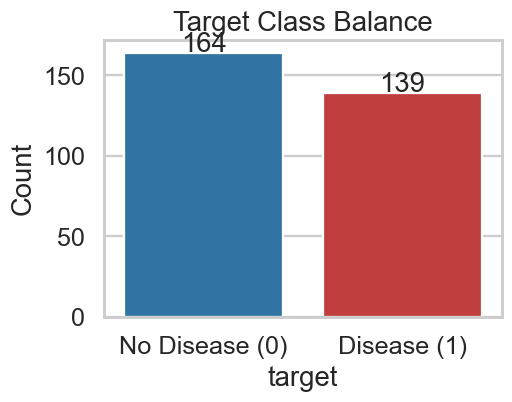

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df['target'].value_counts().sort_index()
sns.barplot(x=counts.index, y=counts.values, palette=['#1f77b4', '#d62728'], ax=ax)
ax.set_xticklabels(['No Disease (0)', 'Disease (1)'])
ax.set_ylabel('Count')
ax.set_title('Target Class Balance')
for i, v in enumerate(counts.values):
    ax.text(i, v + 1, str(v), ha='center')
fig.tight_layout()
fig.savefig('../artifacts/eda_class_balance.png', dpi=150)
plt.show()

## 4. Distribution of numeric features

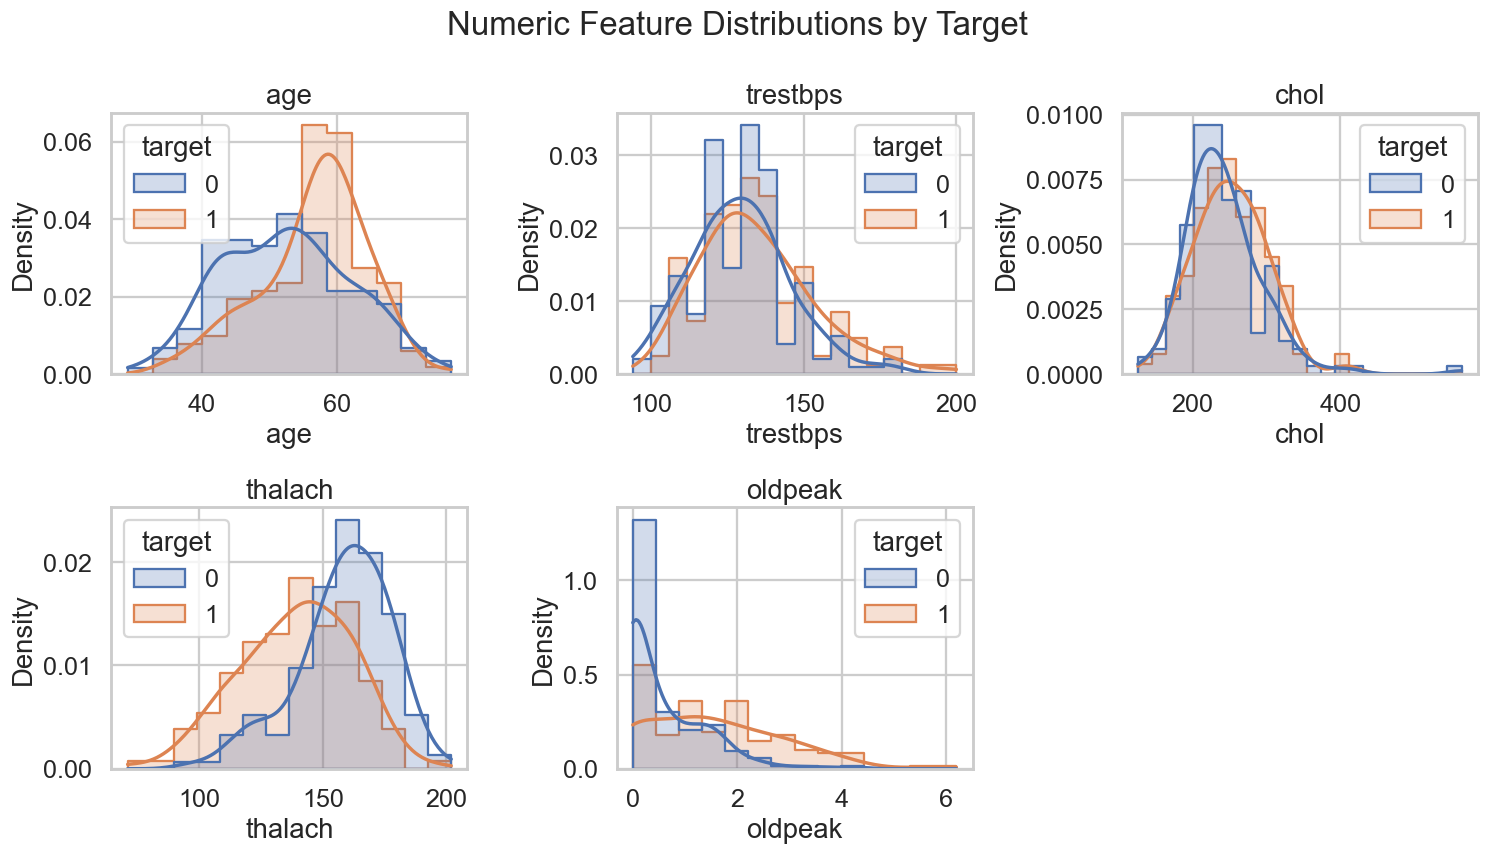

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.flat, NUMERIC_FEATURES):
    sns.histplot(data=df, x=col, hue='target', kde=True, ax=ax, element='step', stat='density', common_norm=False)
    ax.set_title(col)
if len(NUMERIC_FEATURES) < 6:
    for ax in axes.flat[len(NUMERIC_FEATURES):]:
        ax.axis('off')
fig.suptitle('Numeric Feature Distributions by Target')
fig.tight_layout()
fig.savefig('../artifacts/eda_numeric_distributions.png', dpi=150)
plt.show()

## 5. Distribution of categorical features

2026-05-07 21:22:26,345 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-07 21:22:26,346 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-07 21:22:26,355 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-07 21:22:26,356 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-07 21:22:26,365 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


...

2026-05-07 21:22:26,428 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-07 21:22:26,436 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-07 21:22:26,437 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-07 21:22:26,446 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


2026-05-07 21:22:26,448 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


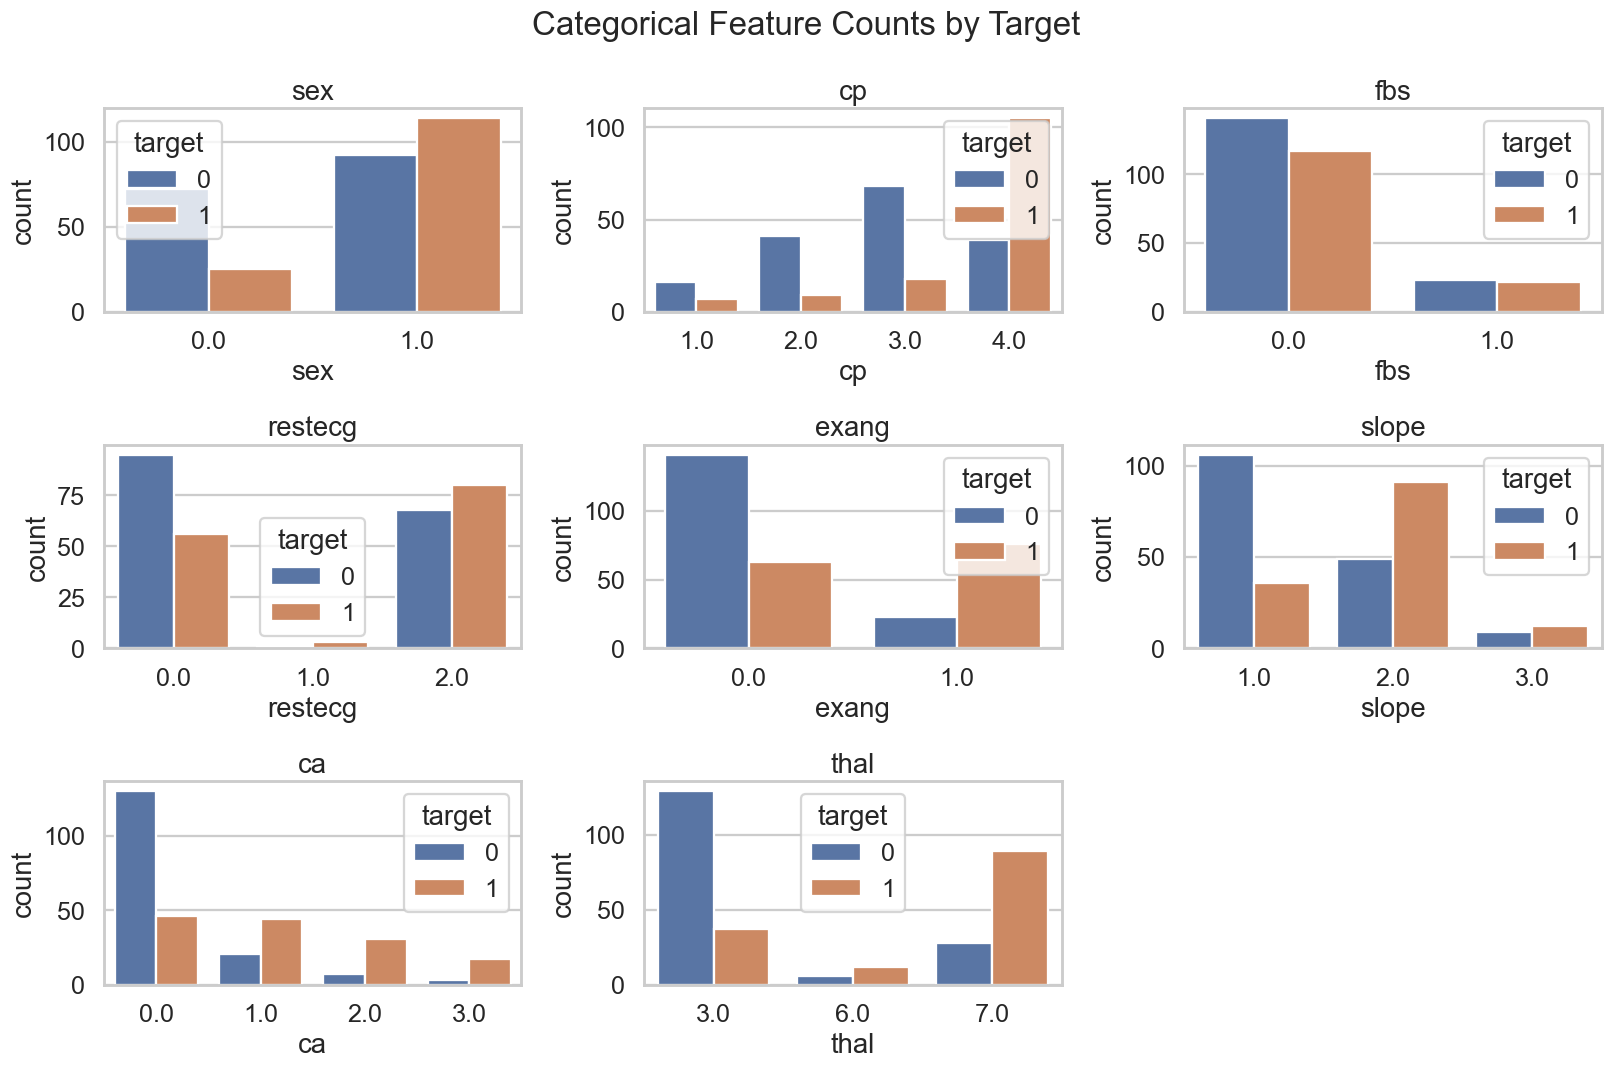

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flat, CATEGORICAL_FEATURES):
    sns.countplot(data=df, x=col, hue='target', ax=ax)
    ax.set_title(col)
for ax in axes.flat[len(CATEGORICAL_FEATURES):]:
    ax.axis('off')
fig.suptitle('Categorical Feature Counts by Target')
fig.tight_layout()
fig.savefig('../artifacts/eda_categorical_distributions.png', dpi=150)
plt.show()

## 6. Correlation heat-map (numeric)

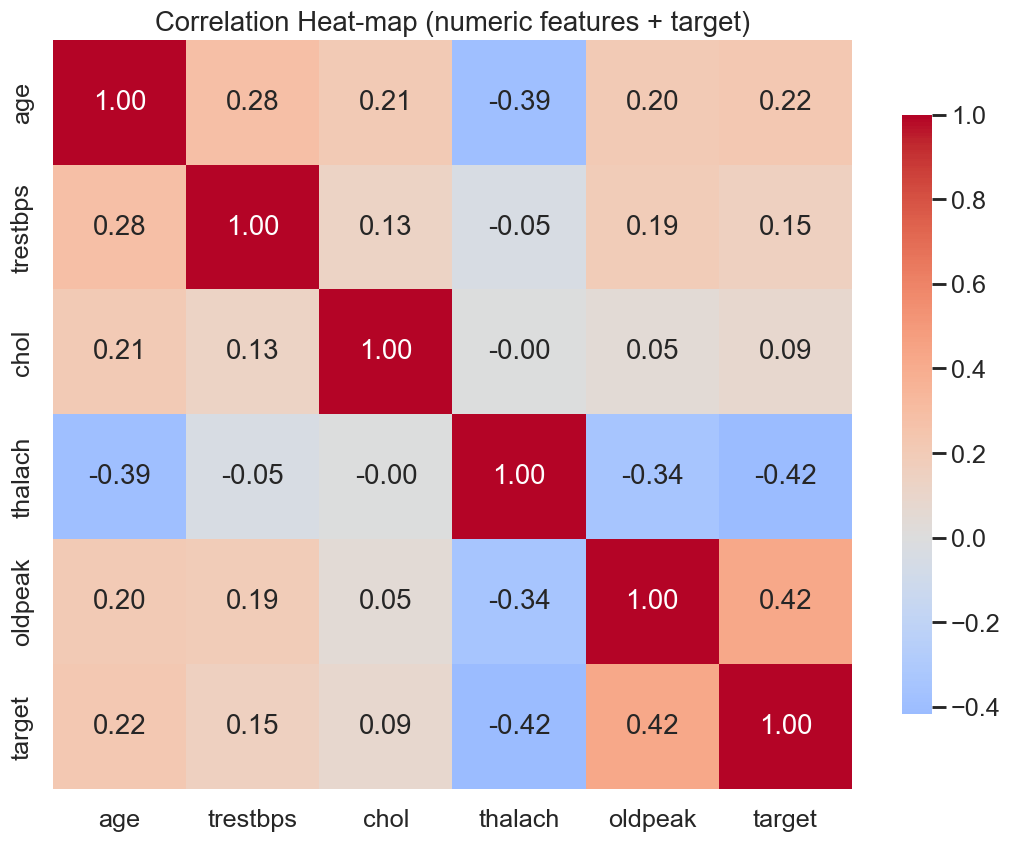

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = df[NUMERIC_FEATURES + ['target']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heat-map (numeric features + target)')
fig.tight_layout()
fig.savefig('../artifacts/eda_correlation_heatmap.png', dpi=150)
plt.show()

## 7. Pairwise relationships of top correlated numeric features with the target

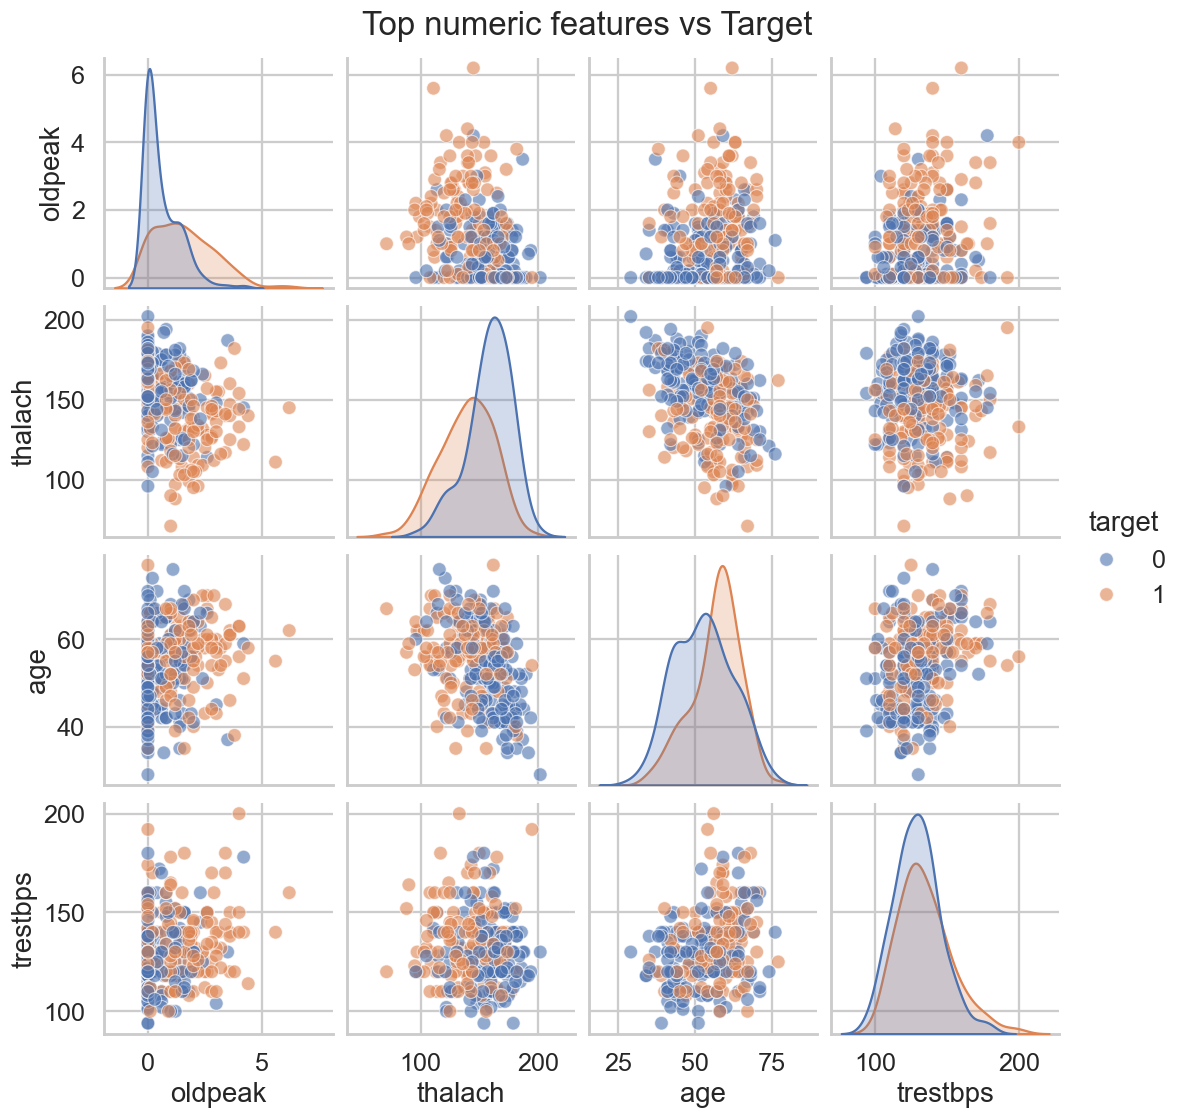

In [9]:
top_numeric = corr['target'].abs().drop('target').sort_values(ascending=False).head(4).index.tolist()
g = sns.pairplot(df[top_numeric + ['target']], hue='target', diag_kind='kde', plot_kws={'alpha': 0.6})
g.fig.suptitle('Top numeric features vs Target', y=1.02)
g.fig.savefig('../artifacts/eda_pairplot.png', dpi=120)
plt.show()

## 8. Take-aways

* **Class balance** is mild (≈54/46) - no resampling needed; we still report ROC-AUC, precision, recall.
* **Missing values** are limited to `ca` and `thal` (≤6 rows). Imputation in the preprocessing pipeline is sufficient.
* **Strong predictors** appear to be `cp`, `oldpeak`, `thalach`, `exang`, `ca`, `thal` - consistent with clinical literature.
* **Model choice** - we will compare a simple Logistic Regression baseline with a more flexible Random Forest, both with tuned hyper-parameters and 5-fold stratified CV.
* **Pipeline** - the `ColumnTransformer` keeps preprocessing reproducible and serialisable alongside the model.